In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0,'../st_validate')
import datetime
import os
import tifffile
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as patches
np.warnings = warnings # this line is necessary to suppress an error produced by the default np.warnings
import sta_validate # import functions for phantom creation and sta tests
import sta # import functions for computing structure tensors and angles
import periodic_kmeans # import functions for angle clustering in 2D
import utils
import visualize
from skimage.transform import resize
from skimage.color import rgb2gray

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

HOME = "/home/brysongray/structure_tensor_validation/"
DATE = datetime.datetime.today().strftime("%m-%d-%y")
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)

# Analyze example microscopy images
## 2D ROI

## Select a slice

In [81]:
dir = "/home/brysongray/nafs/dong/hanpeng-bk-SF221013_02A/SF221013_02A_BK_converted/"
files = sorted([f for f in os.listdir(dir) if 'Overview' not in f])
len(files)

51

## Select second 2D Sample

In [ ]:
n=18
fig, ax = plt.subplots(2,3, figsize=(16,8))
ax = ax.ravel()
for i in range(n, n+6):
    I = tifffile.imread(os.path.join(dir, files[i]))
    ax[i-n].imshow(I)
    ax[i-n].axis("off")
    

In [ ]:
plt.close("all")

In [87]:
# f = files[18]
f = files[30]
print(f)
img = tifffile.imread(os.path.join(dir, f))
img = resize(img, [n//4 for n in img.shape[:2]]+[3,], anti_aliasing=False)
img = rgb2gray(img)

SF221013_02A_BK_JIANDONG_AD_03_04_20x_BF_05.tif


In [88]:
# c = np.array([4009, 8064])
c = np.array([3979, 4780])
large_roi = np.array([c - 445, c + 446])
small_roi = np.array([large_roi[0] + 395, large_roi[1] - 396])
roi1 = img[large_roi[0,0]:large_roi[1,0], large_roi[0,1]:large_roi[1,1]]
roi2 = img[small_roi[0,0]:small_roi[1,0], small_roi[0,1]:small_roi[1,1]]

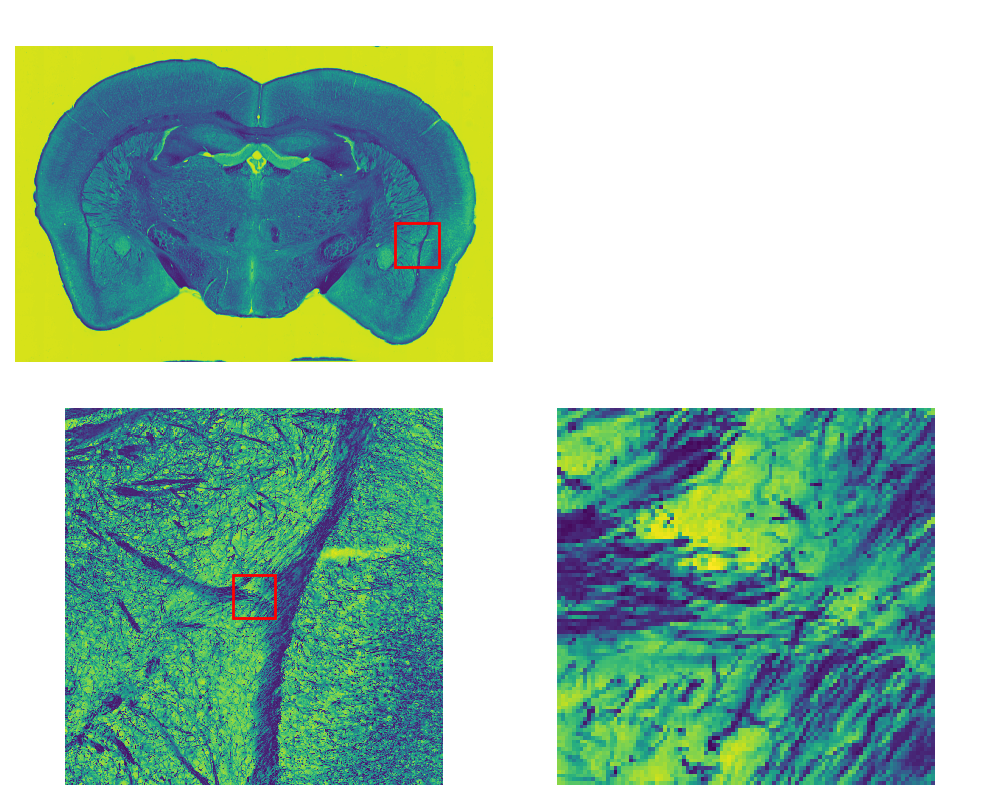

In [84]:
plt.close("all")
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# First plot centered in the first row
ax[0, 0].imshow(img)
ax[0, 0].axis("off")
ax[0, 1].axis("off")  # Leave the second column of the first row empty

# Draw a square bounding box on the first plot
rect = patches.Rectangle(
    (large_roi[0, 1], large_roi[0, 0]),  # Bottom-left corner
    large_roi[1, 1] - large_roi[0, 1],  # Width
    large_roi[1, 0] - large_roi[0, 0],  # Height
    linewidth=2, edgecolor='red', facecolor='none'
)
ax[0, 0].add_patch(rect)

# Second and third plots in the second row
ax[1, 0].imshow(roi1, interpolation='none')
ax[1, 0].axis("off")
# Draw a square bounding box on the second plot
box = np.array([[395,395], [496, 496]])
rect = patches.Rectangle(
    (box[0, 1], box[0, 0]),  # Bottom-left corner
    box[1, 1] - box[0, 1],  # Width
    box[1, 0] - box[0, 0],  # Height
    linewidth=2, edgecolor='red', facecolor='none'
)
ax[1, 0].add_patch(rect)
ax[1, 1].imshow(roi2, interpolation='none')
ax[1, 1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# tifffile.imwrite(f'{HOME}/example_microscopy_data/{f.split(".tif")[0]}_i_{small_roi[0,0]}-{small_roi[1,0]}_j_{small_roi[0,1]}-{small_roi[1,1]}.tif', roi2)

## First 2D sample

In [ ]:
plt.close("all")

In [ ]:
# First plot centered in the first row
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot()
ax.imshow(img, cmap='gray')
ax.axis("off")  # Leave the second column of the first row empty

# Draw a square bounding box on the first plot
rect = patches.Rectangle(
    (large_roi[0, 1], large_roi[0, 0]),  # Bottom-left corner
    large_roi[1, 1] - large_roi[0, 1],  # Width
    large_roi[1, 0] - large_roi[0, 0],  # Height
    linewidth=6, edgecolor='white', facecolor='none'
)
ax.add_patch(rect)
plt.show()
plt.figure(fig)
plt.savefig(os.path.join(HOME,'outputs/figures/figure_for_vaughan/example_2d_whole_slice_2.pdf'))

In [ ]:
J = tifffile.imread("/home/brysongray/structure_tensor_validation/example_microscopy_data/SF221013_02A_BK_JIANDONG_AD_02_04_20x_BF_05_i_3959-4059_j_8014-8114.tif")
# J = tifffile.imread("/home/brysongray/structure_tensor_validation/example_microscopy_data/SF221013_02A_BK_JIANDONG_AD_03_04_20x_BF_05_i_3929-4029_j_4730-4830.tif")
plt.figure()
plt.imshow(J, cmap='gray')
plt.show()

In [ ]:
true_thetas = np.array([140.0, 91.0]) * np.pi/180
# true_thetas = np.array([175.0, 93.0]) * np.pi/180
mean_colors = np.abs([np.sin(true_thetas), np.zeros(len(true_thetas)), np.cos(true_thetas)]).T
fig = visualize.plot_angles(J, means=true_thetas, mean_colors=mean_colors)

plt.figure(fig)
plt.savefig(os.path.join(HOME,'outputs/figures/figure_for_vaughan/example_patch_2d_true_angles_2.pdf'))

## Create a similar phantom

In [ ]:
plt.close("all")
n = (100,100)
d = (1.0, 1.0)
x = [np.arange(ni)*di for ni,di in zip(n,d)]
phantom = sta_validate.make_phantom(x, true_thetas, period=15, width=1.0, inverse=True, mask_frac=0.0, noise=0.02)
# phantom = sta_validate.make_phantom(x, true_thetas, period=15, noise=0.02, width=1.0, inverse=True)
fig = plt.figure()
plt.imshow(phantom, cmap='gray')
plt.axis('off')
plt.savefig(os.path.join(HOME,'outputs/figures/figure_for_vaughan/similar_phantom_2d_2.pdf'))
plt.show()

## Compute STA error for a series of gradient and window kernel standard deviations

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
example_error_2d = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        example_error_2d.append(sta_validate.sta_test(J, g_sigmas[d], w_sigmas[t], true_thetas=true_thetas, crop=crop_all))

example_error_2d = np.array(example_error_2d).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
plt.close('all')

In [ ]:
fig = plt.figure(figsize=(8,8))
ax_image = plt.imshow(example_error_2d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
xticklabels = [f"{x:.2f}" for x in w_sigmas]
yticklabels = [f"{x:.2f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45)
ax.set_yticklabels(yticklabels[::2])
ax.set_xlabel(r"window $\sigma$")
ax.set_ylabel(r"gradient $\sigma$")
# ax.set_title("2D Example Microscopy Errors (degrees)")
cbar = plt.colorbar(ax_image, fraction=0.046, pad=0.04)
plt.figure(fig)
plt.savefig(os.path.join(HOME,f'outputs/figures/figure_for_vaughan/example_patch_2_errors_2d_{DATE}.pdf'))
plt.show()

print(f'argmin: {np.argmin(example_error_2d)}')

## Do the same for the phantom

In [ ]:
phantom_error_2d = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        phantom_error_2d.append(sta_validate.sta_test(phantom, g_sigmas[d], w_sigmas[t], true_thetas=true_thetas, crop=crop_all))

phantom_error_2d = np.array(phantom_error_2d).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
plt.close("all")

In [ ]:
fig = plt.figure(figsize=(8,8))
ax_image = plt.imshow(phantom_error_2d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
# rect1 = patches.Rectangle((0.5,1.5),1,1, color='yellow', fill=False, linewidth=2)
rect1 = patches.Rectangle((1.5,1.5),1,1, color='yellow', fill=False, linewidth=2)
# rect2 = patches.Rectangle((1.5,8.5),1,1, color='orange', fill=False, linewidth=2)
rect2 = patches.Rectangle((1.5,8.5),1,1, color='orange', fill=False, linewidth=2)
# rect3 = patches.Rectangle((8.5,-0.5),1,1, color='cyan', fill=False, linewidth=2)
rect3 = patches.Rectangle((8.5,-0.5),1,1, color='cyan', fill=False, linewidth=2)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
xticklabels = [f"{x:.2f}" for x in w_sigmas]
yticklabels = [f"{x:.2f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45)
ax.set_yticklabels(yticklabels[::2])
ax.set_xlabel(r"window $\sigma$")
ax.set_ylabel(r"gradient $\sigma$")
# ax.set_title("Phantom Errors (degrees)")
cbar = plt.colorbar(ax_image, fraction=0.046, pad=0.04)
# cbar.ax.set_aspect(20)  # Adjust the aspect ratio of the colorbar
plt.figure(fig)
plt.savefig(os.path.join(HOME,f'outputs/figures/figure_for_vaughan/phantom_2_errors_2d_{DATE}.pdf'))
plt.show()


In [ ]:
g = g_sigmas[2]
w = w_sigmas[2]
# g = g_sigmas[2]
# w = w_sigmas[1]
S = sta.structure_tensor(J, g, w)
angles = sta.angles(S)
angles = np.where(angles < 0.0, angles + np.pi, angles)
mu = periodic_kmeans.periodic_kmeans(angles.flatten(), k=2, period=np.pi)
mean_colors = np.abs([np.sin(mu), np.zeros(len(mu)), np.cos(mu)]).T
mean_colors /= np.max(mean_colors, axis=1)[:,None]

# get the primary direction to color the histogram
single_mean = periodic_kmeans.periodic_mean(angles.flatten(), x = np.arange(180)*np.pi/180, period=np.pi)
color = np.abs([np.sin(single_mean), 0.0, np.cos(single_mean)])
color /= color.max()

fig = visualize.plot_angles(J, angles=angles, means=mu, mean_colors=mean_colors, border_color=None, hist_color=color)

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/2d_st_angles_{g:.2f}_{w:.2f}_2.pdf'))

In [ ]:
plt.close("all")

In [ ]:
g = g_sigmas[9]
w = w_sigmas[2]
# g = g_sigmas[9]
# w = w_sigmas[2]
S = sta.structure_tensor(J, g, w)
angles = sta.angles(S)
angles = np.where(angles < 0.0, angles + np.pi, angles)
mu = periodic_kmeans.periodic_kmeans(angles.flatten(), k=2, period=np.pi)
mean_colors = np.abs([np.sin(mu), np.zeros(len(mu)), np.cos(mu)]).T
mean_colors /= np.max(mean_colors, axis=1)[:,None]

# get the primary direction to color the histogram
single_mean = periodic_kmeans.periodic_mean(angles.flatten(), x = np.arange(180)*np.pi/180, period=np.pi)
color = np.abs([np.sin(single_mean), 0.0, np.cos(single_mean)])
color /= color.max()

fig = visualize.plot_angles(J, angles=angles, means=mu, mean_colors=mean_colors, hist_color=color, border_color=None)

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/2d_st_angles_{g:.2f}_{w:.2f}_2.pdf'))

In [ ]:
g =  g_sigmas[0]
w = w_sigmas[9]
# g =  g_sigmas[0]
# w = w_sigmas[9]
S = sta.structure_tensor(J, g, w)
angles = sta.angles(S)
angles = np.where(angles < 0.0, angles + np.pi, angles)
mu = periodic_kmeans.periodic_kmeans(angles.flatten(), k=2, period=np.pi)
mean_colors = np.abs([np.sin(mu), np.zeros(len(mu)), np.cos(mu)]).T
mean_colors /= np.max(mean_colors, axis=1)[:,None]

# get the primary direction to color the histogram
single_mean = periodic_kmeans.periodic_mean(angles.flatten(), x = np.arange(180)*np.pi/180, period=np.pi)
color = np.abs([np.sin(single_mean), 0.0, np.cos(single_mean)])
color /= color.max()

fig = visualize.plot_angles(J, angles=angles, means=mu, mean_colors=mean_colors, hist_color=color, border_color=None)

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/2d_st_angles_{g:.2f}_{w:.2f}_2.pdf'))

# Make large roi figure

In [14]:
def plot_odfs_2d(image, angles, tile_size=None, odf_colors=False, n_bins=200, markersize=2, rect=None, rect_color='r', **kwargs):
    """ plot 2d odfs (polar histograms of angles) overlayed on a grayscale image.

    Parameters
    ----------
    image : Two-dimensional ndarray
        The image to show.
    angles : Two-dimensional ndarray
        The angles derived from the image.
    nbins : int
        The number of bins to use for the polar histograms
    kwargs : arguments given to create the figure.
    """

    if tile_size is not None:
        # gather the angles into tiles. i.e. angles is reshaped from (i,j) -> (i//tile_size, j//tilesize, tile_size**2)
        angles = utils.gather(angles[...,None], tile_size).squeeze()
        # Note: this operation crops angles so that it divides into a whole number of tiles.
        # The new shape is (tile_size * i//tile_size, tile_size * j//tile_size).
        # The image must be cropped to match
        ntiles_i = angles.shape[0]
        ntiles_j = angles.shape[1]
        image = image[:tile_size*ntiles_i, :tile_size*ntiles_j]
    else:
        ntiles_i = angles.shape[0]
        ntiles_j = angles.shape[1]

    # compute odfs as histograms of angles 
    t = np.arange(n_bins+1)*(2*np.pi/n_bins) - np.pi
    polar_hist = []
    colors = []
    for i in range(angles.shape[0]):
        for j in range(angles.shape[1]):
            angles_flat = angles[i,j]
            if odf_colors: # compute the primary direction in each tile and use it to set the color
                angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
                x = np.arange(100) * np.pi/100
                mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
                # periodic_kmeans = PeriodicKMeans(angles_hemi[...,None], period=np.pi, no_of_clusters=1)
                # _, _, centers = periodic_kmeans.clustering()
                # mu = np.array(centers).squeeze()
                mu = mu.squeeze()
                c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
                c /= c.max()
                colors.append(c)
            angles_ = np.where(angles_flat<0, angles_flat+np.pi, angles_flat-np.pi)
            angles_sym = np.concatenate((angles_flat, angles_), axis=0)
            x, bins = np.histogram(angles_sym, t)

            # smooth the histogram by truncating the data in the frequency domain.
            xf = np.fft.rfft(x)
            n = np.arange(len(xf))
            xf = xf * np.exp(-0.1*n)
            xfinv = np.fft.irfft(xf,n_bins+1)
            xfinv = xfinv / np.sum(xfinv)

            polar_hist.append([xfinv, bins])
    
    # plot polar histograms overlayed on the image
    plt.interactive(False)
    fig = plt.figure(**kwargs)

    aspect = image.shape[0]/image.shape[1]
    fig.set_size_inches(9,9*aspect)
    # plot image

    ax_image = fig.add_axes([0.,0.,1.,1.])
    ax_image.imshow(image, cmap='gray', interpolation=None)#, vmin=-0.2, vmax=np.quantile(image, q=.98))
    ax_image.axis('off')

    if rect is not None:
        r = patches.Rectangle((rect[0],rect[1]), rect[2], rect[3], linewidth=6, edgecolor=rect_color, facecolor='None')
        ax_image.add_patch(r)
    
    # plot polar histograms
    # set the bottom-left coordinates for each odf in units of figure size 
    xs = np.arange(0., 1., 1/ntiles_j)
    ys = np.arange((ntiles_i-1)/ntiles_i, -1/ntiles_i, -1/ntiles_i)

    padding = 0.01
    for i in range(len(polar_hist)):
        polar_coords = [xs[i%ntiles_j]+padding, ys[i//ntiles_j]+padding, 1/ntiles_j-padding*2, 1/ntiles_i-padding*2] # [left, bottom, width, height]
        ax_polar = fig.add_axes(polar_coords, projection = 'polar')
        # ax_polar.patch.set_alpha(0)
        if odf_colors:
            color = colors[i]
        else:
            color = 'r'
        # ax_polar.plot(t, polar_hist[i], linewidth=markersize, c=color)
        xfinv, bins = polar_hist[i]
        for j in range(len(bins)-1):
            ax_polar.bar(bins[j], xfinv[j], width=bins[j + 1] - bins[j], align='edge', alpha=1.0, color=color)

        ax_polar.set_theta_offset(-np.pi/2)
        ax_polar.set_yticklabels([])
        ax_polar.grid(False)
        ax_polar.axis('off')

    plt.show()

    return fig
    # fig.figure

In [ ]:
fig = plt.figure(figsize=(10,10))
rect = [4*99,4*99,99,99]
ax_image = fig.add_axes([0.,0.,1.,1.])
ax_image.imshow(roi1, cmap='gray', interpolation=None)
ax_image.axis('off')
r = patches.Rectangle((rect[0],rect[1]), rect[2], rect[3], linewidth=6, edgecolor='white', facecolor='None')
ax_image.add_patch(r)
plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/large_roi_2d_original_2.pdf'))
plt.show()

In [ ]:
plt.close("all")

## Good parameter settings ($\sigma_g$: 0.67, $\sigma_w$: 0.55)

In [ ]:
g = g_sigmas[2]
w = w_sigmas[2]
# g = g_sigmas[2]
# w = w_sigmas[1]
S = sta.structure_tensor(roi1, g, w)
thetas = sta.angles(S)
print(thetas.shape)
rect = [4*99,4*99,99,99]
# fig = plot_odfs_2d(roi1, thetas, tile_size=33, odf_colors=True, n_bins=150, figsize=(8,8), markersize=3.0, rect=[5*33, 5*33, 33, 33], rect_color='yellow')
fig = plot_odfs_2d(roi1, thetas, tile_size=99, odf_colors=True, n_bins=150, figsize=(20,20), rect=rect, rect_color='yellow')
plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/large_roi_2d_g-{g:.2f}_w-{w:.2f}_2.pdf'))

## Bad parameter settings ($\sigma_g$: 2.5, $\sigma_w$: 1.1)

In [ ]:
g = g_sigmas[9]
w = w_sigmas[2]
# g = g_sigmas[9]
# w = w_sigmas[2]
S = sta.structure_tensor(roi1, g, w)
thetas = sta.angles(S)
print(thetas.shape)
rect = [4*99,4*99,99,99]
fig = plot_odfs_2d(roi1, thetas, tile_size=99, odf_colors=True, n_bins=150, figsize=(20,20), rect=rect, rect_color='orange')
plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/large_roi_2d_g-{g:.2f}_w-{w:.2f}_2.pdf'))

## Bad parameter settings ($\sigma_g$: 0.15, $\sigma_w$: 5.0)

(891, 891)


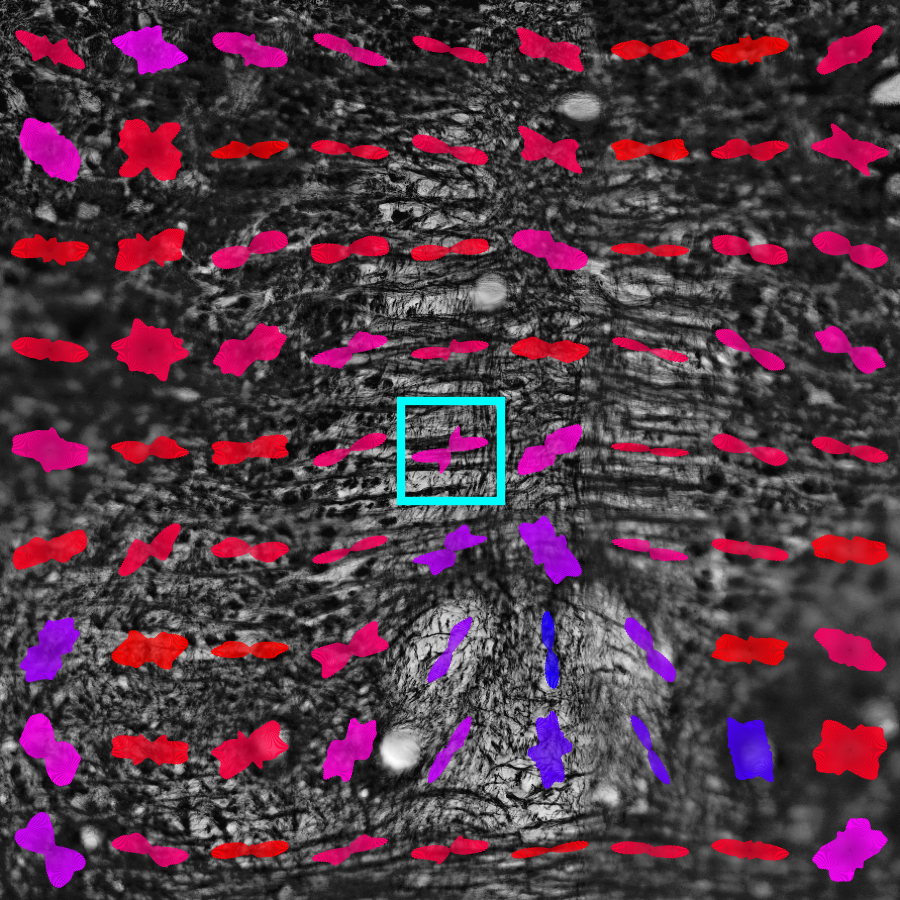

In [89]:
plt.close("all")
g = g_sigmas[0]
w = w_sigmas[9]
# g = g_sigmas[0]
# w = w_sigmas[9]
S = sta.structure_tensor(roi1, g, w)
thetas = sta.angles(S)
print(thetas.shape)
rect = [4*99,4*99,99,99]
fig = plot_odfs_2d(roi1, thetas, tile_size=99, odf_colors=True, n_bins=150, figsize=(20,20), rect=rect, rect_color='cyan')
plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/2d_figure_1/large_roi_2d_g-{g:.2f}_w-{w:.2f}_2.pdf'))

## Color wheel

In [ ]:
x = np.linspace(0, 2, 1000) - 1.0
X = np.stack(np.meshgrid(x,x, indexing='ij'))

t = np.arctan2(X[1], X[0])

C = np.abs(np.stack([np.sin(t), np.zeros_like(t), np.cos(t)])) # color [R 0 B]

C = C / C.max(axis=0)

mask = np.linalg.norm(X, axis=0) > 1.0
C = C.transpose(1,2,0)
C[np.linalg.norm(X, axis=0) > 1.0] = 1.0

fig = plt.figure()
plt.imshow(C)
plt.axis('off')
plt.show()

# plt.figure(fig)
# plt.savefig(os.path.join(HOME, 'outputs/figures/red-blue_color_wheel.png'))

## 3D ROI

## Load 3D image

In [3]:
path = '/home/brysongray/nafs/bryson/data/amg_data/YCHM171LCRP.tif'
# path = "/nafs/dtward/bryson/data/amg_data/YCHM171LCRP.tif"

I = tifffile.imread(path)
I = I/255
# I = I[26:55, 22:958, 58:1334]
I = I[26:55, 230:958, 58:870]
print(f"Image shape before correction: {I.shape}")
# original resolution is 0.8658x0.8658x2.4092 um
# upsample to isotropic by trilinear interpolatation
dI = (2.4092, 0.8658, 0.8658)
I_ = utils.anisotropy_correction(I, dI)
print(f"Image shape after correction: {I_.shape}")
I_ = I_[:78] # crop interpolation artifact
# Small ROI
I_small = I_[:, 416:520, 348:464]
# I_down = resize(I_, [x/4.0 for x in I_.shape])
# I_small_down = I_down[:, 156:182, 87:116]
# I_small_down = I_down[:, 104:130, 87:116]

Image shape before correction: (29, 728, 812)
Image shape after correction: (81, 728, 812)


In [ ]:
I_small.shape

In [ ]:
# tifffile.imwrite("/home/brysongray/structure_tensor_validation/example_microscopy_data/two_angle_roi_3d_i_26-55_j_646-750_k_406-522_corrected.tif", I_small)

In [ ]:
I_small = tifffile.imread("../example_microscopy_data/two_angle_roi_3d_i_26-55_j_646-750_k_406-522_corrected.tif")

## Large ROI

In [ ]:
[(624+22)-104*4, (728+22)+104*2, (348+58)-116*3, (464+58)+116*3]

In [ ]:
plt.figure()
plt.imshow(I_small.max(axis=0), cmap="gray", vmin=-0.0)#, vmax=np.quantile(I_, q=0.999))
plt.show()

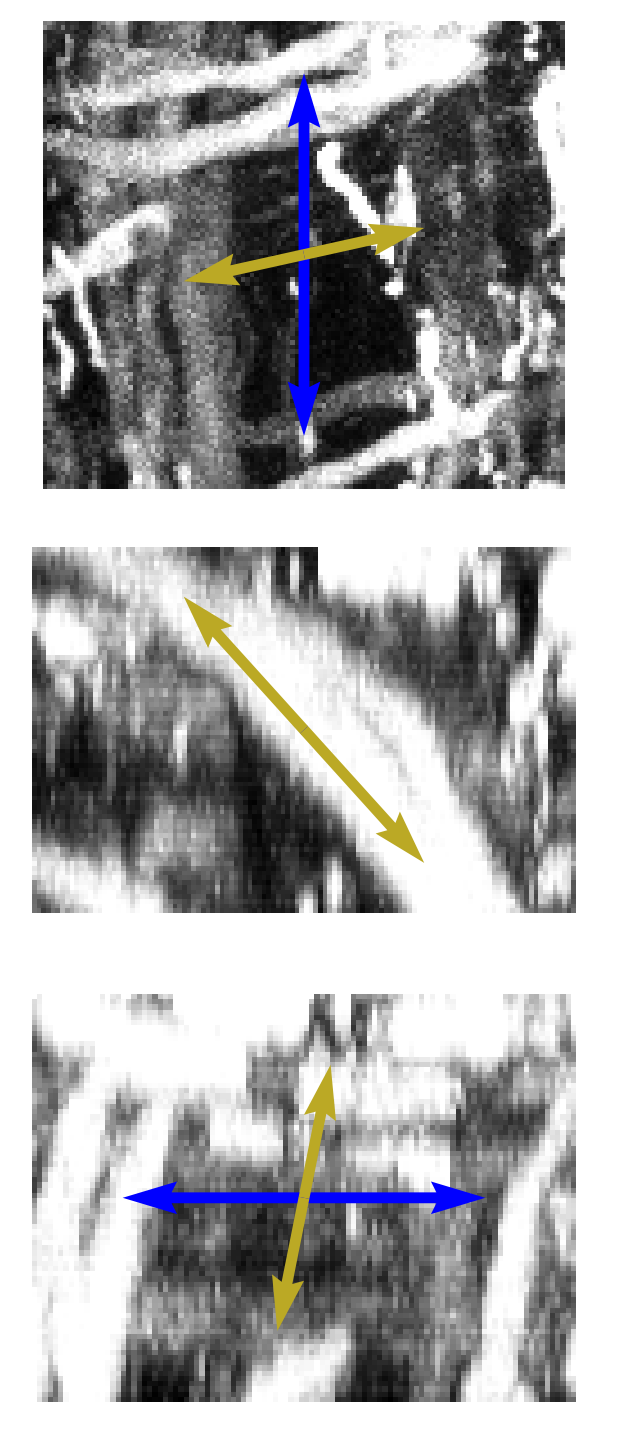

In [15]:
# load 3d histology patch

# path = os.path.join(HOME, "example_microscopy_data/two_angle_roi_3d_i_26-55_j_646-750_k_406-522.tif")
# I = tifffile.imread(path)
# I_down = resize(I, [x/4.0 for x in I.shape])
m1 = [0.0, 1.0, 0.0]
m1 /= np.linalg.norm(m1)
m2 = [0.63218647, -0.14, 0.70]
m2 /= np.linalg.norm(m2)
label_means_3d = np.array([m1,m2]) # plot_angles_3d assumes this is in "xyz" order.

fig = visualize.plot_angles_3d(image=I_small, means=label_means_3d, mip=True, vertical=True)

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/example_patch_1_3d_true_angles.pdf'))

plt.show()

## Create a similar phantom

In [10]:
plt.close('all')

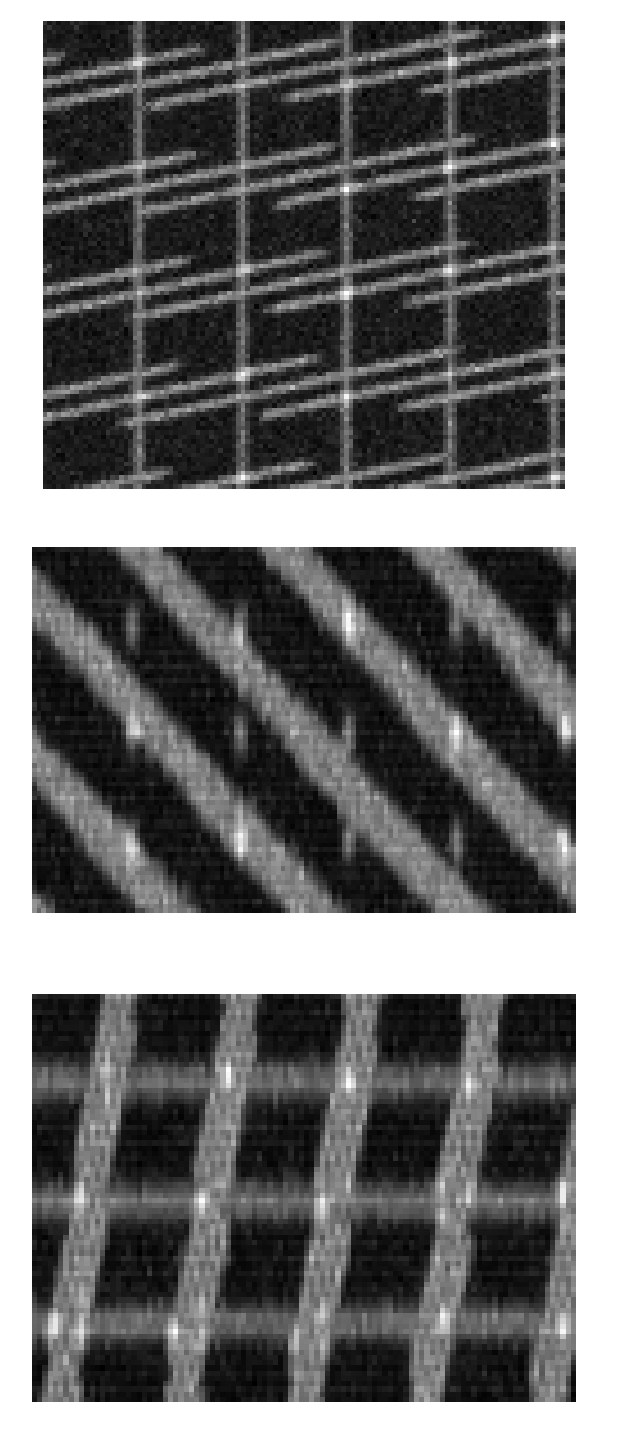

In [11]:
# n = (78, 104, 116)
# d = (1.0, 1.0, 1.0)
n = (29, 104, 116)
d = (2.4092, 0.8658, 0.8658)
x = [np.arange(ni)*di for ni,di in zip(n,d)]
true_thetas = np.array([np.arccos(label_means_3d[:,2]), np.arctan2(label_means_3d[:,0],label_means_3d[:,1])]).T

phantom = sta_validate.make_phantom(x, true_thetas, period=20, width=1, inverse=False, mask_frac=0.0, noise=0.07)
phantom = phantom[:78]
fig = visualize.plot_angles_3d(image=phantom, means=None, mip=True, vertical=True)
plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/similar_phantom_1_3d.pdf'))
plt.show()

## Compute STA error for a series of gradient and window kernel standard deviations

## For the real ROI

In [ ]:
plt.close("all")

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
error = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        error.append(sta_validate.sta_test(I_small, g_sigmas[d], w_sigmas[t], true_thetas=true_thetas, crop=crop_all))

example_error_3d = np.array(error).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
fig = plt.figure(figsize=(8,8))
ax_image = plt.imshow(example_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
xticklabels = [f"{x:.2f}" for x in w_sigmas]
yticklabels = [f"{x:.2f}" for x in g_sigmas*3]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45)
ax.set_yticklabels(yticklabels[::2])
ax.set_xlabel(r"window $\sigma$")
ax.set_ylabel(r"gradient $\sigma$")
# ax.set_title("3D Example Microscopy Errors (degrees)")
cbar = plt.colorbar(ax_image, fraction=0.046, pad=0.04)
plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_2/example_patch_2_errors_3d_{DATE}.pdf'))
plt.show()

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
error = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        error.append(sta_validate.sta_test(I_small, g_sigmas[d]*3, w_sigmas[t], true_thetas=true_thetas, crop=crop_all))

example_error_3d = np.array(error).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
fig = plt.figure(figsize=(8,8))
ax_image = plt.imshow(example_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
xticklabels = [f"{x:.2f}" for x in w_sigmas]
yticklabels = [f"{x:.2f}" for x in g_sigmas*3]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45)
ax.set_yticklabels(yticklabels[::2])
ax.set_xlabel(r"window $\sigma$")
ax.set_ylabel(r"gradient $\sigma$")
# ax.set_title("3D Example Microscopy Errors (degrees)")
cbar = plt.colorbar(ax_image, fraction=0.046, pad=0.04)
# plt.colorbar()
plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/example_patch_1_errors_3d_3xg_{DATE}.pdf'))
plt.show()

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
error = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        error.append(sta_validate.sta_test(I_small, g_sigmas[d]+0.3, w_sigmas[t], true_thetas=true_thetas, crop=crop_all))

example_error_3d = np.array(error).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
fig = plt.figure()
ax_image = plt.imshow(example_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
xticklabels = [f"{x:.1f}" for x in w_sigmas]
yticklabels = [f"{x:.1f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=60)
ax.set_yticklabels(yticklabels[::2])
ax.set_title("3D Example Microscopy Errors (degrees)")
plt.colorbar()
plt.show()

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10) + 4.0
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
error = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        error.append(sta_validate.sta_test(I_small, g_sigmas[d], w_sigmas[t], true_thetas=true_thetas, crop=crop_all))

example_error_3d = np.array(error).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
fig = plt.figure()
ax_image = plt.imshow(example_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
xticklabels = [f"{x:.1f}" for x in w_sigmas]
yticklabels = [f"{x:.1f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=60)
ax.set_yticklabels(yticklabels[::2])
ax.set_title("3D Example Microscopy Errors (degrees)")
plt.colorbar()
plt.show()

## and for the phantom

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
phantom_error_3d = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        # crop_end = round(n[1]/n[0]) - 1
        phantom_error_3d.append(sta_validate.sta_test(phantom, g_sigmas[d], w_sigmas[t], true_thetas=true_thetas, crop=crop_all))#, crop_end=crop_end))

phantom_error_3d = np.array(phantom_error_3d).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
fig = plt.figure(figsize=(8,8))
ax_image = plt.imshow(phantom_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
rect1 = patches.Rectangle((0.5,8.5),1,1, color='yellow', fill=False, linewidth=2)
rect2 = patches.Rectangle((4.5,3.5),1,1, color='orange', fill=False, linewidth=2)
rect3 = patches.Rectangle((8.5,-0.5),1,1, color='cyan', fill=False, linewidth=2)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
xticklabels = [f"{x:.2f}" for x in w_sigmas]
yticklabels = [f"{x:.2f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45)
ax.set_yticklabels(yticklabels[::2])
ax.set_xlabel(r"window $\sigma$")
ax.set_ylabel(r"gradient $\sigma$")
# ax.set_title("3D Phantom Errors (degrees)")
cbar = plt.colorbar(ax_image, fraction=0.046, pad=0.04)
plt.figure(fig)
plt.savefig(os.path.join(HOME,f'outputs/figures/figure_for_vaughan/3d_figure_1/phantom_1_errors_3d_{DATE}.pdf'))
plt.show()


## Large ROI for 3D

In [ ]:
plt.figure()
plt.imshow(I_.max(axis=0), cmap="gray")#, vmax=np.quantile(I_, q=0.999))
plt.axis("off")
plt.show()

In [12]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)

In [13]:
g = g_sigmas[9]
w = w_sigmas[1]

S = sta.structure_tensor(I_, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
print(f"gradient sigma: {g}\n\
tensor sigma: {w}")

# turn vectors into angles
x = vectors[...,0]
y = vectors[...,1]
thetas = np.stack((x,y), axis=-1)
thetas = utils.vec_to_theta(thetas)
thetas = utils.gather(thetas[...,None], patch_size=(78,104,116)).squeeze()

# rect = [3*116, 4*104, 116, 104]
rect = [4*116, 4*104, 116, 104]
fig = plot_odfs_2d(I_.max(axis=0), thetas, odf_colors=True, n_bins=150, markersize=2.0, rect=rect, rect_color="yellow")

plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_2/large_roi_2_3d_g-{g:.2f}_w-{w:.2f}.pdf'))

gradient sigma: 2.5
tensor sigma: 0.5555555555555556


NameError: name 'plot_odfs_2d' is not defined

In [ ]:
g = g_sigmas[9]
w = w_sigmas[1]

# patch = I_down[:, 26*6:26*7, 29*3:29*4]
patch = I_small
S = sta.structure_tensor(patch, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=2)

# get the primary direction to color the histogram
x = vectors[...,0]
y = vectors[...,1]
angles = np.stack((x, y), axis=-1)
angles = utils.vec_to_theta(angles)
angles_flat = angles.flatten()

angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
x = np.arange(100) * np.pi/100
mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
mu = mu.squeeze()
c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
c /= c.max()

fig = visualize.plot_angles_3d(image=patch, vectors=vectors, means=means, mip=True, border_color=None, hist_color=c, vertical=True)

diff = periodic_kmeans.distance_3d(means, label_means_3d)
diff = periodic_kmeans.multiple_exclusive_distances(diff)
diff = np.mean(diff)
error = np.mean(diff) * 180/np.pi
print(error)

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_2/example_patch_3d_g-{g:.2f}_w-{w:.2f}.pdf'))

In [ ]:
g = g_sigmas[4]
w = w_sigmas[5]
# g = g_sigmas[5]
# w = w_sigmas[5]

S = sta.structure_tensor(I_, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
print(f"gradient sigma: {g}\n\
tensor sigma: {w}")

# turn vectors into angles
x = vectors[...,0]
y = vectors[...,1]
thetas = np.stack((x,y), axis=-1)
thetas = utils.vec_to_theta(thetas)
thetas = utils.gather(thetas[...,None], patch_size=(78,104,116)).squeeze()

rect = [3*116, 4*104, 116, 104]
# rect = [4*116, 4*104, 116, 104]
fig = plot_odfs_2d(I_.max(axis=0), thetas, odf_colors=True, n_bins=150, markersize=2.0, rect=rect, rect_color="orange")

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_1/large_roi_1_3d_g-{g:.2f}_w-{w:.2f}.pdf'))

In [ ]:
g = g_sigmas[4]
w = w_sigmas[5]
# g = g_sigmas[5]
# w = w_sigmas[5]

# patch = I_down[:, 26*6:26*7, 29*3:29*4]
patch = I_small
S = sta.structure_tensor(patch, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=2)

# get the primary direction to color the histogram
x = vectors[...,0]
y = vectors[...,1]
angles = np.stack((x, y), axis=-1)
angles = utils.vec_to_theta(angles)
angles_flat = angles.flatten()

angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
x = np.arange(100) * np.pi/100
mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
mu = mu.squeeze()
c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
c /= c.max()

fig = visualize.plot_angles_3d(image=patch, vectors=vectors, means=means, mip=True, border_color=None, hist_color=c, vertical=True)

diff = periodic_kmeans.distance_3d(means, label_means_3d)
diff = periodic_kmeans.multiple_exclusive_distances(diff)
diff = np.mean(diff)
error = np.mean(diff) * 180/np.pi
print(error)

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_1/example_patch_3d_g-{g:.2f}_w-{w:.2f}.pdf'))

In [ ]:
g = g_sigmas[0]
w = w_sigmas[9]

S = sta.structure_tensor(I_, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
print(f"gradient sigma: {g}\n\
tensor sigma: {w}")

# turn vectors into angles
x = vectors[...,0]
y = vectors[...,1]
thetas = np.stack((x,y), axis=-1)
thetas = utils.vec_to_theta(thetas)
thetas = utils.gather(thetas[...,None], patch_size=(78,104,116)).squeeze()

# rect = [3*116, 4*104, 116, 104]
rect = [4*116, 4*104, 116, 104]
fig = plot_odfs_2d(I_.max(axis=0), thetas, odf_colors=True, n_bins=150, markersize=2.0, rect=rect, rect_color="cyan")

# plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_2/large_roi_2_3d_g-{g:.2f}_w-{w:.2f}.pdf'))

In [ ]:
g = g_sigmas[0]
w = w_sigmas[9]

patch = I_small
S = sta.structure_tensor(patch, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=2)

# get the primary direction to color the histogram
x = vectors[...,0]
y = vectors[...,1]
angles = np.stack((x, y), axis=-1)
angles = utils.vec_to_theta(angles)
angles_flat = angles.flatten()

angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
x = np.arange(100) * np.pi/100
mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
mu = mu.squeeze()
c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
c /= c.max()

fig = visualize.plot_angles_3d(image=patch, vectors=vectors, means=means, mip=True, border_color=None, hist_color=c, vertical=True)

diff = periodic_kmeans.distance_3d(means, label_means_3d)
diff = periodic_kmeans.multiple_exclusive_distances(diff)
diff = np.mean(diff)
error = np.mean(diff) * 180/np.pi
print(error)

plt.figure(fig)
plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_2/example_patch_3d_g-{g:.2f}_w-{w:.2f}.pdf'))

## Second patch

In [16]:
plt.close("all")

In [17]:
path = '/home/brysongray/nafs/bryson/data/amg_data/YCHM171LCRP.tif'
# path = "/nafs/dtward/bryson/data/amg_data/YCHM171LCRP.tif"

I = tifffile.imread(path)
I = I/255

In [18]:
c = np.array([44, int(round(616 * 1028/890.04)), int(round(2106 * 2828/2448.49))])
I_ = I[c[0]-14:c[0]+15, c[1]-364-104:c[1]+364-104, c[2]-406-116:c[2]+406-116]
print(f"Image shape before correction: {I_.shape}")
# original resolution is 0.8658x0.8658x2.4092 um
# upsample to isotropic by trilinear interpolatation
dI = (2.4092, 0.8658, 0.8658)
I_ = utils.anisotropy_correction(I_, dI)
print(f"Image shape after correction: {I_.shape}")
I_ = I_[:78] # crop interpolation artifact
# Small ROI
# I_small = I_[:, 624:728, 348:464]
I_small = I_[:, 364-52+104:364+52+104, 406-58+116:406+58+116]

Image shape before correction: (29, 728, 812)
Image shape after correction: (81, 728, 812)


In [ ]:
plt.figure()
plt.imshow(I_.max(axis=0))
plt.show()

In [ ]:
plt.close("all")
fig, ax = plt.subplots(1,3, figsize=(10,5))
ax[0].imshow(I_small.max(axis=0))
ax[1].imshow(I_small.max(axis=1))
ax[2].imshow(I_small.max(axis=2))
plt.show()
# ax[0].imshow(I_small[I_small.shape[0]//2])
# ax[1].imshow(I_small[:,52])
# ax[2].imshow(I_small[I_small.shape[2]//2])

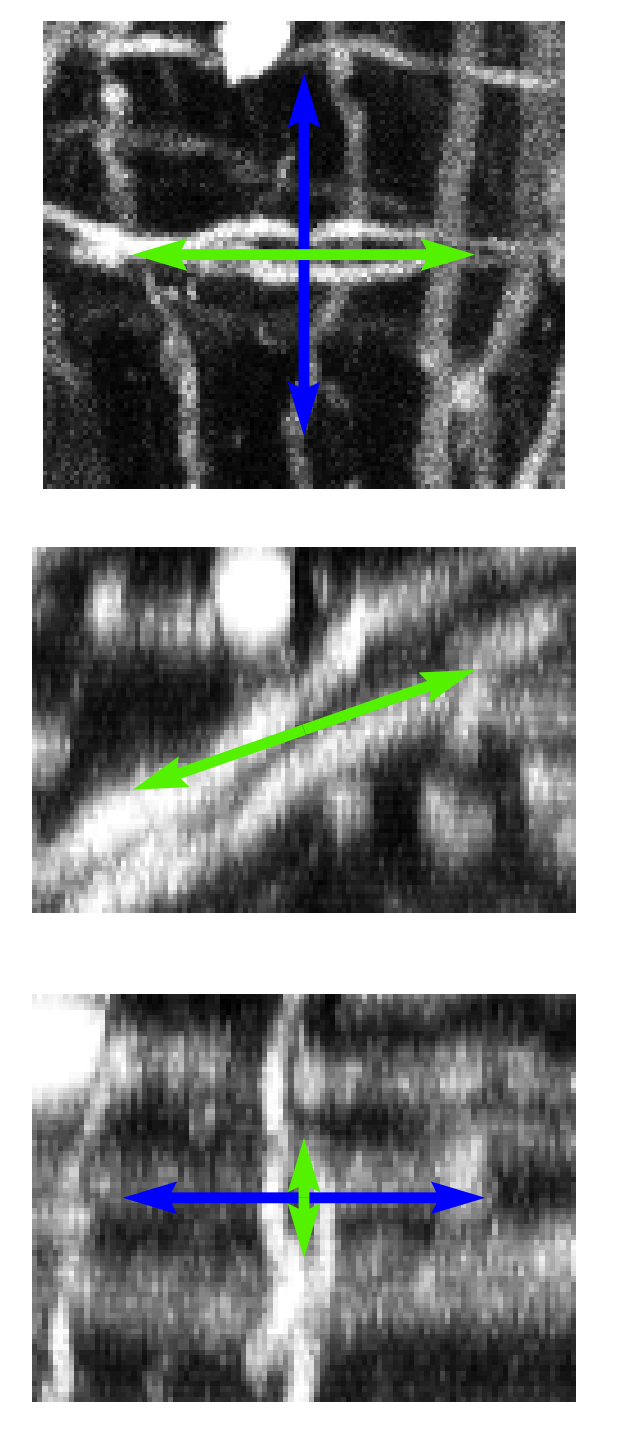

In [ ]:
m1 = [0.0, 1.0, 0.0]
m1 /= np.linalg.norm(m1)
m2 = [-1.00, 0.0, 0.70]
m2 /= np.linalg.norm(m2)
label_means_3d = np.array([m1,m2])

fig = visualize.plot_angles_3d(image=I_small, means=label_means_3d, mip=True, vertical=True)
plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_2/example_patch_2_3d_true_angles.pdf'))
plt.show()

## create a similar phantom

In [ ]:
plt.close("all")

In [ ]:
n = (29, 104, 116)
d = (2.4092, 0.8658, 0.8658)
x = [np.arange(ni)*di for ni,di in zip(n,d)]
true_thetas = np.array([np.arccos(label_means_3d[:,2]), np.arctan2(label_means_3d[:,0],label_means_3d[:,1])]).T

phantom = sta_validate.make_phantom(x, true_thetas, period=20, width=1, inverse=False, noise=0.07)
phantom = phantom[:78]
fig = visualize.plot_angles_3d(image=phantom, means=None, mip=True, vertical=True)
plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure_2/similar_phantom_2_3d.pdf'))
plt.show()

In [ ]:
plt.close('all')

In [ ]:
g = g_sigmas[4]
w = w_sigmas[1]

# patch = I_down[:, 26*6:26*7, 29*3:29*4]
patch = I_small
S = sta.structure_tensor(patch, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
# means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=2)
means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=1)

# get the primary direction to color the histogram
x = vectors[...,0]
y = vectors[...,1]
angles = np.stack((x, y), axis=-1)
angles = utils.vec_to_theta(angles)
angles_flat = angles.flatten()

angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
x = np.arange(100) * np.pi/100
mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
mu = mu.squeeze()
c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
c /= c.max()

fig = visualize.plot_angles_3d(image=patch, vectors=vectors, means=means, mip=True, border_color='yellow', hist_color=c, vertical=False)


In [ ]:
mu = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=1)
diff = np.arccos(np.abs(mu.dot(true_means_3d[:,::-1].T)))
error = np.mean(diff) * 180/np.pi
print(error)

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
error = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        error.append(sta_validate.sta_test(I_small, g_sigmas[d], w_sigmas[t], true_thetas=true_thetas, crop=crop_all))
        # error.append(sta_validate.sta_test(I_small, g_sigmas[d]*4, w_sigmas[t]*4, true_thetas=true_thetas, crop=crop_all))

example_error_3d = np.array(error).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
fig = plt.figure()
ax_image = plt.imshow(example_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
xticklabels = [f"{x:.1f}" for x in w_sigmas]
yticklabels = [f"{x:.1f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=60)
ax.set_yticklabels(yticklabels[::2])
ax.set_title("3D Example Microscopy 2 Errors (degrees)")
plt.colorbar()
plt.show()

In [ ]:
g_sigmas = np.linspace(start=0.15, stop=2.5, num=10)
w_sigmas = np.linspace(start=0.0, stop=5.0, num=10)
error = []
for d in range(len(g_sigmas)):
    for t in range(len(w_sigmas)):
        crop_all = round(max(d,t)*8/3) # two-thirds the radius of the largest kernel (the default kernel radius is 4).
        error.append(sta_validate.sta_test(phantom, g_sigmas[d], w_sigmas[t], true_thetas=true_thetas, crop=crop_all))
        # error.append(sta_validate.sta_test(phantom, g_sigmas[d]*4, w_sigmas[t]*4, true_thetas=true_thetas, crop=crop_all))

phantom_error_3d = np.array(error).reshape((len(w_sigmas),len(g_sigmas)))

In [ ]:
fig = plt.figure()
ax_image = plt.imshow(phantom_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
rect1 = patches.Rectangle((0.5,3.5),1,1, color='yellow', fill=False, linewidth=2)
rect2 = patches.Rectangle((8.5,8.5),1,1, color='orange', fill=False, linewidth=2)
rect3 = patches.Rectangle((8.5,-0.5),1,1, color='cyan', fill=False, linewidth=2)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
xticklabels = [f"{x:.3f}" for x in w_sigmas]
yticklabels = [f"{x:.3f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45)
ax.set_yticklabels(yticklabels[::2])
ax.set_xlabel(r"window $\sigma$")
ax.set_ylabel(r"gradient $\sigma$")
# ax.set_title("3D Phantom Errors (degrees)")
plt.colorbar()
plt.show()

# plt.figure(fig)
# plt.savefig(os.path.join(HOME,'outputs/figures/for_vaughan/phantom_errors_3d_labeled.pdf'))
# plt.savefig('phantom_errors_3d_labeled.pdf')

In [ ]:
fig = plt.figure()
ax_image = plt.imshow(phantom_error_3d, vmin=0.0, vmax=50.0)
ax = ax_image.axes
rect1 = patches.Rectangle((0.5,3.5),1,1, color='yellow', fill=False, linewidth=2)
rect2 = patches.Rectangle((8.5,8.5),1,1, color='orange', fill=False, linewidth=2)
rect3 = patches.Rectangle((8.5,-0.5),1,1, color='cyan', fill=False, linewidth=2)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
xticklabels = [f"{x:.3f}" for x in w_sigmas]
yticklabels = [f"{x:.3f}" for x in g_sigmas]
ax.set_xticks(np.arange(len(g_sigmas))[::2])
ax.set_yticks(np.arange(len(w_sigmas))[::2])
ax.set_xticklabels(xticklabels[::2], rotation=45)
ax.set_yticklabels(yticklabels[::2])
ax.set_xlabel(r"window $\sigma$")
ax.set_ylabel(r"gradient $\sigma$")
# ax.set_title("3D Phantom Errors (degrees)")
plt.colorbar()
plt.show()

# plt.figure(fig)
# plt.savefig(os.path.join(HOME,'outputs/figures/for_vaughan/phantom_errors_3d_labeled.pdf'))
# plt.savefig('phantom_errors_3d_labeled.pdf')

In [ ]:
g = g_sigmas[4]
w = w_sigmas[1]

S = sta.structure_tensor(I_large, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
print(f"gradient sigma: {g}\n\
tensor sigma: {w}")

# turn vectors into angles
x = vectors[...,0]
y = vectors[...,1]
thetas = np.stack((x,y), axis=-1)
thetas = utils.vec_to_theta(thetas)
thetas = utils.gather(thetas[...,None], patch_size=(78,104,116)).squeeze()

rect = [4*116, 4*104, 116, 104]
fig = plot_odfs_2d(I_large.max(axis=0), thetas, odf_colors=True, n_bins=150, markersize=2.0, rect=rect, rect_color="yellow")

# plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure/large_roi_3d_g-{g:.2f}_w-{w:.2f}_composite.pdf'))

In [ ]:
g = g_sigmas[4]
w = w_sigmas[1]

# patch = I_down[:, 26*6:26*7, 29*3:29*4]
patch = I_small
S = sta.structure_tensor(patch, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=2)

# get the primary direction to color the histogram
x = vectors[...,0]
y = vectors[...,1]
angles = np.stack((x, y), axis=-1)
angles = utils.vec_to_theta(angles)
angles_flat = angles.flatten()

angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
x = np.arange(100) * np.pi/100
mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
mu = mu.squeeze()
c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
c /= c.max()

fig = visualize.plot_angles_3d(image=patch, vectors=vectors, means=means, mip=True, border_color='yellow', hist_color=c, vertical=True)

In [ ]:
g = g_sigmas[0]
w = w_sigmas[9]

S = sta.structure_tensor(I_large, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
print(f"gradient sigma: {g}\n\
tensor sigma: {w}")

# turn vectors into angles
x = vectors[...,0]
y = vectors[...,1]
thetas = np.stack((x,y), axis=-1)
thetas = utils.vec_to_theta(thetas)
thetas = utils.gather(thetas[...,None], patch_size=(78,104,116)).squeeze()

rect = [4*116, 4*104, 116, 104]
fig = plot_odfs_2d(I_large.max(axis=0), thetas, odf_colors=True, n_bins=150, markersize=2.0, rect=rect, rect_color="yellow")

# plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure/large_roi_3d_g-{g:.2f}_w-{w:.2f}_composite.pdf'))

In [ ]:
g = g_sigmas[0]
w = w_sigmas[9]

# patch = I_down[:, 26*6:26*7, 29*3:29*4]
patch = I_small
S = sta.structure_tensor(patch, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=2)

# get the primary direction to color the histogram
x = vectors[...,0]
y = vectors[...,1]
angles = np.stack((x, y), axis=-1)
angles = utils.vec_to_theta(angles)
angles_flat = angles.flatten()

angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
x = np.arange(100) * np.pi/100
mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
mu = mu.squeeze()
c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
c /= c.max()

fig = visualize.plot_angles_3d(image=patch, vectors=vectors, means=means, mip=True, border_color='yellow', hist_color=c, vertical=True)

In [ ]:
g = g_sigmas[9]
w = w_sigmas[9]

S = sta.structure_tensor(I_large, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
print(f"gradient sigma: {g}\n\
tensor sigma: {w}")

# turn vectors into angles
x = vectors[...,0]
y = vectors[...,1]
thetas = np.stack((x,y), axis=-1)
thetas = utils.vec_to_theta(thetas)
thetas = utils.gather(thetas[...,None], patch_size=(78,104,116)).squeeze()

rect = [4*116, 4*104, 116, 104]
fig = plot_odfs_2d(I_large.max(axis=0), thetas, odf_colors=True, n_bins=150, markersize=2.0, rect=rect, rect_color="yellow")

# plt.figure(fig)
# plt.savefig(os.path.join(HOME, f'outputs/figures/figure_for_vaughan/3d_figure/large_roi_3d_g-{g:.2f}_w-{w:.2f}_composite.pdf'))

In [ ]:
g = g_sigmas[9]
w = w_sigmas[9]

# patch = I_down[:, 26*6:26*7, 29*3:29*4]
patch = I_small
S = sta.structure_tensor(patch, derivative_sigma=g, tensor_sigma=w)
vectors = sta.angles(S, cartesian=True)
means = periodic_kmeans.apsym_kmeans(vectors.reshape(-1,3), k=2)

# get the primary direction to color the histogram
x = vectors[...,0]
y = vectors[...,1]
angles = np.stack((x, y), axis=-1)
angles = utils.vec_to_theta(angles)
angles_flat = angles.flatten()

angles_hemi = np.where(angles_flat<0, angles_flat+np.pi, angles_flat) # set angles to range [0,pi] for periodic_mean
x = np.arange(100) * np.pi/100
mu = periodic_kmeans.periodic_mean(angles_hemi, x, period=np.pi)
mu = mu.squeeze()
c = np.abs(np.array([[np.sin(mu), 0.0, np.cos(mu)]]))
c /= c.max()

fig = visualize.plot_angles_3d(image=patch, vectors=vectors, means=means, mip=True, border_color='yellow', hist_color=c, vertical=True)

## Legends

[[ 0.          0.76980036]
 [-0.66666667 -0.38490018]
 [ 0.66666667 -0.38490018]]


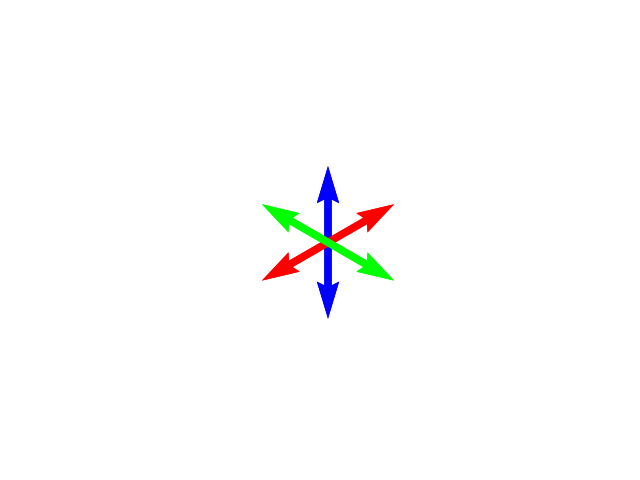

In [37]:
vectors = np.array([[1.0,0.0,0.0],
                    [0.0,1.0,0.0],
                    [0.0,0.0,1.0]])
colors = np.stack((vectors[2], vectors[0], vectors[1]))
normal = np.array([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)])
e1 = np.array([normal[0], -normal[1], -normal[2]])
e2 = np.cross(e1,normal)
L = np.stack([e2,e1])
vectors_p = sta.project_to_plane(vectors=vectors, normal=normal, L=L)
# vectors_p = vectors_p / np.linalg.norm(vectors_p[1])
plt.figure()
print(vectors_p)
for i,m in enumerate(vectors_p):
    plt.quiver(0, 0, m[0], m[1], scale=5, width=0.015, color=colors[i])
    plt.quiver(0, 0, m[0], m[1], scale=5, width=0.015, color=colors[i])
    plt.quiver(0, 0, -m[0], -m[1], scale=5, width=0.015, color=colors[i])
    plt.quiver(0, 0, -m[0], -m[1], scale=5, width=0.015, color=colors[i])
plt.axis('off')
plt.show()

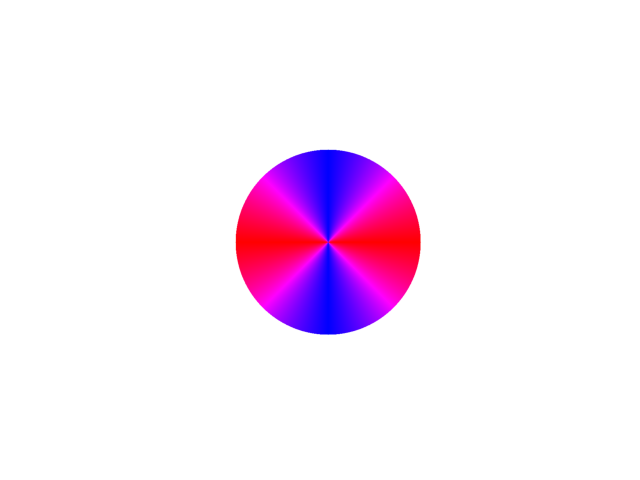

In [4]:
x = [np.arange(1000) - 500, np.arange(1000) - 500]
X = np.stack(np.meshgrid(*x, indexing='xy'), axis=-1)

X_theta = np.array(utils.vec_to_theta(X))
color_wheel = visualize.angle_to_rgb(X_theta, cmap='rb')
background = np.ones_like(color_wheel)
X_ = np.stack((X,X,X), axis=-2)
color_wheel = np.where(np.linalg.norm(X_, axis=-1) > 250, background, color_wheel)

plt.imshow(color_wheel)
plt.axis('off')
plt.show()